In [2]:
import os
import shutil
from google.colab import drive

drive.mount('/content/drive')


data_src = '/content/drive/MyDrive/data'
data_dst = '/content/data'
model_src_dir = '/content/drive/MyDrive/carla_models'
models_to_copy = [
    'has_pedestrian_best.pth',
    'has_vehicle_best.pth',
    'has_traffic_light_best.pth'
]

# Ensure the base destination directory exists
os.makedirs(data_dst, exist_ok=True)

# Copy only the 'test' directory
test_data_src = os.path.join(data_src, 'test')
test_data_dst = os.path.join(data_dst, 'test')

if os.path.exists(test_data_src):
    print(f"Copying test data from {test_data_src}...")
    shutil.copytree(test_data_src, test_data_dst, dirs_exist_ok=True)
else:
    print(f"Test data path not found: {test_data_src}")

for model_file in models_to_copy:
    src_path = os.path.join(model_src_dir, model_file)
    dst_path = os.path.join('/content', model_file)
    if os.path.exists(src_path):
        print(f"Copying {model_file}...")
        shutil.copy2(src_path, dst_path)
    else:
        print(f"Model file not found: {src_path}")

print("done")

Mounted at /content/drive
Copying test data from /content/drive/MyDrive/data/test...
Copying has_pedestrian_best.pth...
Copying has_vehicle_best.pth...
Copying has_traffic_light_best.pth...
done


In [3]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Models
def load_model(checkpoint_path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    return model

ped_model = load_model('has_pedestrian_best.pth')
veh_model = load_model('has_vehicle_best.pth')
tl_model = load_model('has_traffic_light_best.pth')

print("Models loaded successfully.")

# 3. CARLADataset Class Definition
class CARLADataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        raw_val = self.df.iloc[idx, 0]
        # Based on diagnostic, files are 6-digit padded .jpg
        if isinstance(raw_val, (int, float)):
            filename = f"{int(raw_val):06d}.jpg"
        else:
            filename = str(raw_val)
            if not (filename.endswith('.jpg') or filename.endswith('.png')):
                filename += '.jpg'

        img_name = os.path.join(self.img_dir, filename)

        # Fallback to search if the first attempt fails
        if not os.path.exists(img_name):
            # Try direct string match without padding
            alt_filename = f"{str(raw_val)}.jpg"
            img_name = os.path.join(self.img_dir, alt_filename)

        if not os.path.exists(img_name):
            search_pattern = os.path.join(os.path.dirname(self.img_dir), "**", f"*{str(raw_val)}*")
            found = glob.glob(search_pattern, recursive=True)
            if found: img_name = found[0]
            else: raise FileNotFoundError(f"Could not find image for index {raw_val} in {self.img_dir}")

        image = Image.open(img_name).convert('RGB')
        labels = torch.tensor(self.df.iloc[idx, 1:4].values.astype('float32'))
        if self.transform: image = self.transform(image)
        return image, labels

base_path = '/content/data'
cat_folder = 'test-town-01'
csv_path = os.path.join(base_path, cat_folder, 'labels.csv')
img_path = os.path.join(base_path, cat_folder, 'rgb-front')

if os.path.exists(csv_path):
    dataset = CARLADataset(csv_file=csv_path, img_dir=img_path, transform=data_transforms)
    plt.figure(figsize=(15, 5))
    samples_found = 0
    for i in range(len(dataset)):
        if samples_found >= 5: break
        try:
            img, label = dataset[i]
            inv_img = img.permute(1, 2, 0).cpu().numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
            plt.subplot(1, 5, samples_found + 1)
            plt.imshow(inv_img.clip(0, 1))
            plt.title(f"Sample {i}")
            plt.axis('off')
            samples_found += 1
        except Exception as e:
            continue
    plt.show()
else:
    print(f"Could not find labels at {csv_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models loaded successfully.
Could not find labels at /content/data/test-town-01/labels.csv


In [4]:
def fgsm_attack(model, image, label, epsilon, targeted=False):
    # To suppress detection (reduce recall), we need to move AWAY from the positive class.
    # For a sample where ground truth is 1, moving 'away' means decreasing the logit.
    # This is achieved by SUBTRACTING the gradient sign of the loss w.r.t. the positive label.
    img_copy = image.clone().detach()
    img_copy.requires_grad = True

    output = model(img_copy)
    criterion = nn.BCEWithLogitsLoss()

    # For suppression, we always want to drive the model's output towards 0.0
    # So, the target for the loss function should be a tensor of zeros.
    target_for_loss = torch.zeros_like(output)
    loss = criterion(output, target_for_loss)

    model.zero_grad()
    loss.backward()

    data_grad = img_copy.grad.data
    sign_data_grad = data_grad.sign()

    # SUBTRACT gradient to decrease the probability of the current label (Suppression)
    perturbed_image = img_copy + epsilon * sign_data_grad

    return torch.clamp(perturbed_image, 0, 1)


--- Evaluating Model: Pedestrian ---
Epsilon: 0.01 | Clean Pred: False (0.2936) | Adv Pred: False (0.2658) | Flipped: False


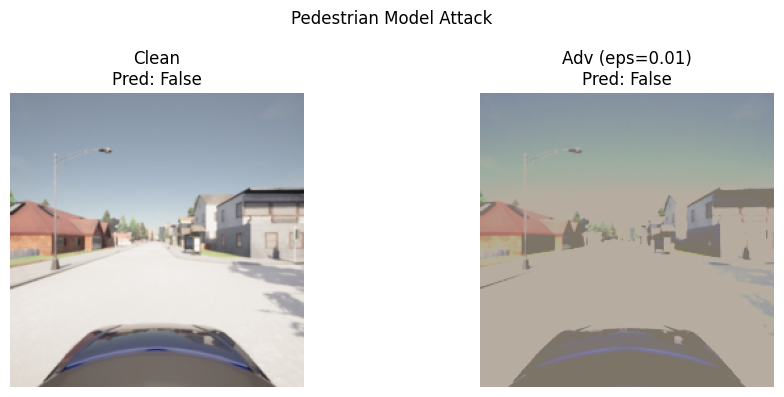

Epsilon: 0.05 | Clean Pred: False (0.2936) | Adv Pred: False (0.3031) | Flipped: False


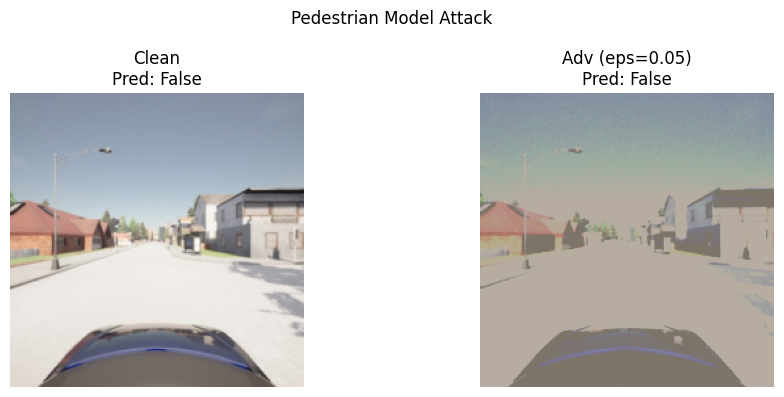

Epsilon: 0.1 | Clean Pred: False (0.2936) | Adv Pred: False (0.2592) | Flipped: False


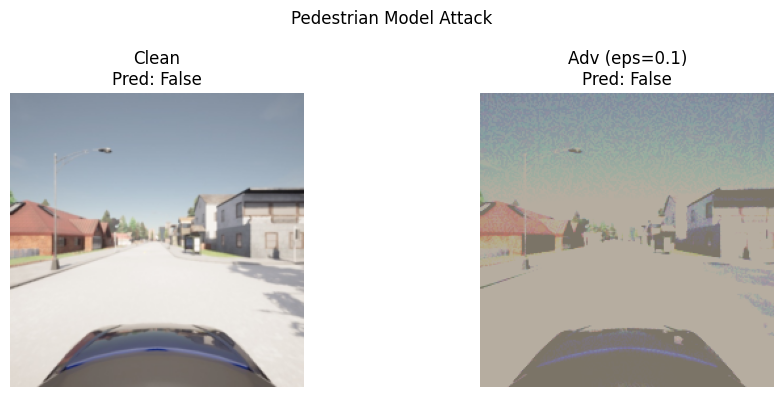


--- Evaluating Model: Vehicle ---
Epsilon: 0.01 | Clean Pred: False (0.2946) | Adv Pred: True (0.5189) | Flipped: True


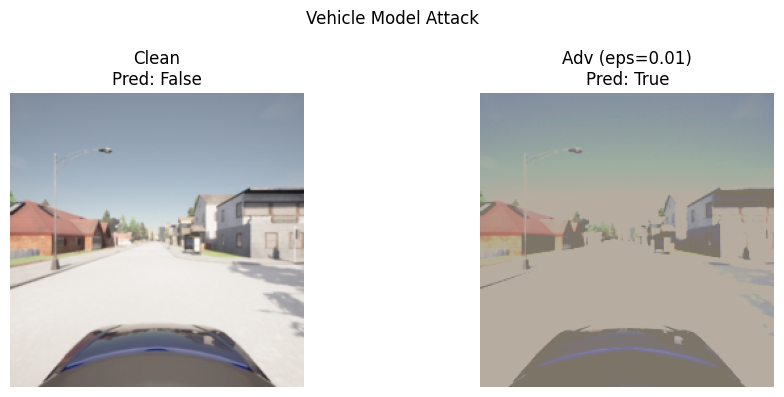

Epsilon: 0.05 | Clean Pred: False (0.2946) | Adv Pred: False (0.4096) | Flipped: False


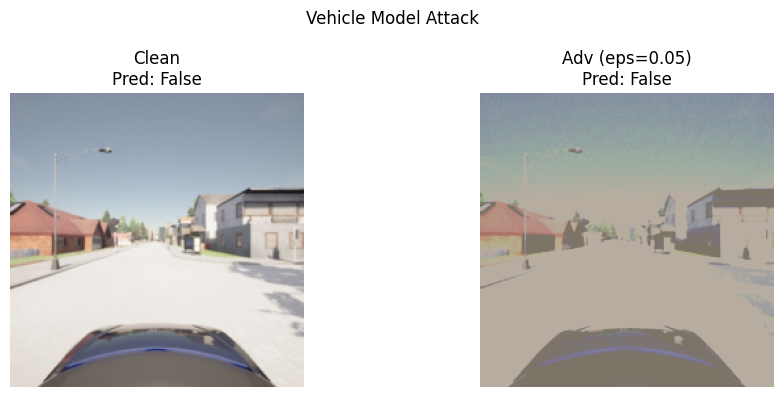

Epsilon: 0.1 | Clean Pred: False (0.2946) | Adv Pred: False (0.4993) | Flipped: False


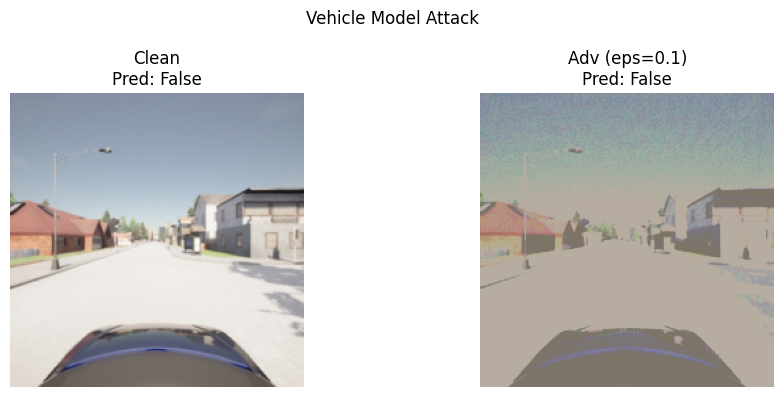


--- Evaluating Model: Traffic Light ---
Epsilon: 0.01 | Clean Pred: True (0.6839) | Adv Pred: True (0.5530) | Flipped: False


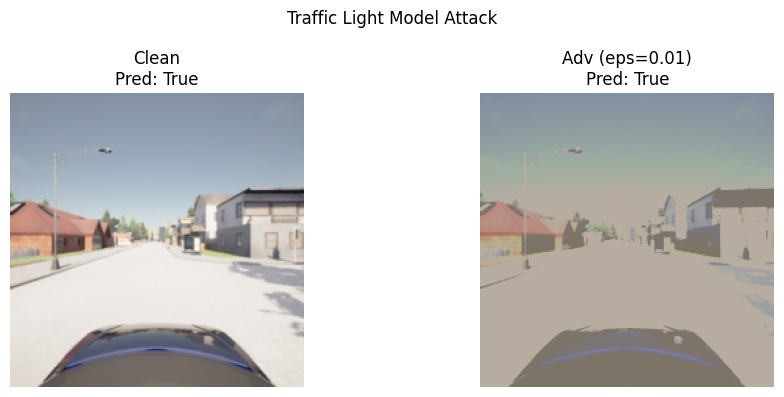

Epsilon: 0.05 | Clean Pred: True (0.6839) | Adv Pred: False (0.1889) | Flipped: True


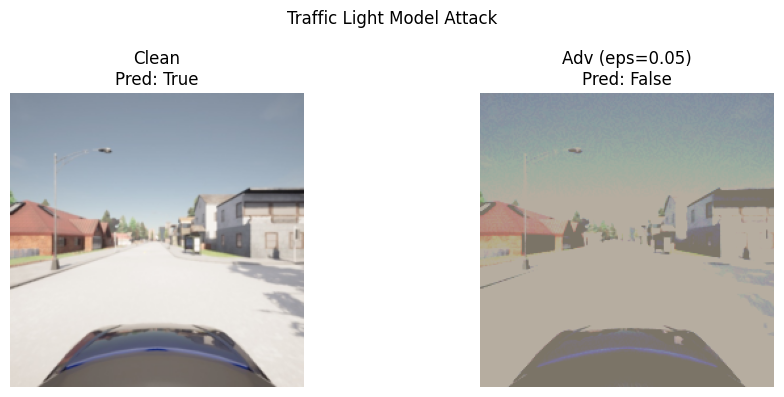

Epsilon: 0.1 | Clean Pred: True (0.6839) | Adv Pred: False (0.2466) | Flipped: True


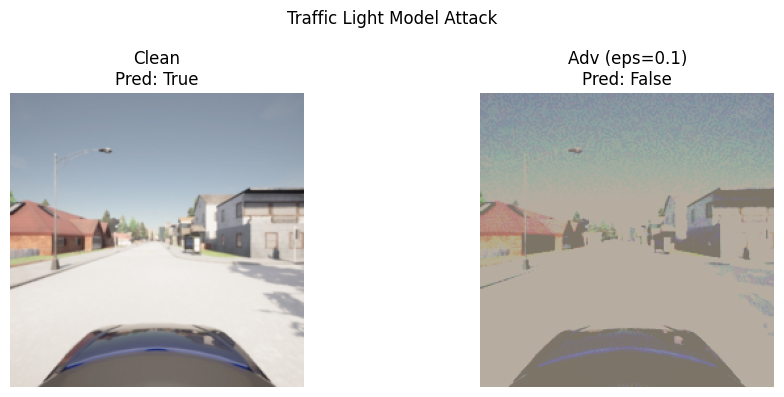

In [7]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Ensure dataset is defined with the correct path
correct_csv_path = '/content/data/test/labels.csv'
correct_img_path = '/content/data/test/rgb-front'

if 'dataset' not in globals():
    if os.path.exists(correct_csv_path):
        dataset = CARLADataset(csv_file=correct_csv_path, img_dir=correct_img_path, transform=data_transforms)
    else:
        raise FileNotFoundError(f"Could not find labels at {correct_csv_path}. Please check your data paths.")

epsilons = [0.01, 0.05, 0.1]
model_list = [
    ("Pedestrian", ped_model, 0),
    ("Vehicle", veh_model, 1),
    ("Traffic Light", tl_model, 2)
]

# Standard ImageNet normalization parameters for denormalization
mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
std = torch.tensor([0.229, 0.224, 0.225]).to(device)

def denormalize(tensor):
    # tensor shape: [1, 3, H, W]
    return tensor.clone().detach().squeeze().permute(1, 2, 0) * std + mean

# the same clean test image from the dataset
clean_img_raw, clean_labels = dataset[0]
clean_img = clean_img_raw.unsqueeze(0).to(device)

for model_name, model, label_idx in model_list:
    print(f"\n--- Evaluating Model: {model_name} ---")
    target_label = clean_labels[label_idx].unsqueeze(0).to(device)

    # Get clean prediction
    with torch.no_grad():
        clean_output = model(clean_img)
        clean_prob = torch.sigmoid(clean_output).item()
        clean_pred = clean_prob >= 0.5

    for eps in epsilons:
        # Generate adversarial image
        adv_img = fgsm_attack(model, clean_img.clone(), target_label, eps)

        # Get adversarial prediction
        with torch.no_grad():
            adv_output = model(adv_img)
            adv_prob = torch.sigmoid(adv_output).item()
            adv_pred = adv_prob >= 0.5

        prediction_flipped = clean_pred != adv_pred

        print(f"Epsilon: {eps} | Clean Pred: {clean_pred} ({clean_prob:.4f}) | Adv Pred: {adv_pred} ({adv_prob:.4f}) | Flipped: {prediction_flipped}")

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Clean Image
        axes[0].imshow(denormalize(clean_img).cpu().numpy().clip(0, 1))
        axes[0].set_title(f"Clean\nPred: {clean_pred}")
        axes[0].axis('off')

        # Adversarial Image
        axes[1].imshow(denormalize(adv_img).cpu().numpy().clip(0, 1))
        axes[1].set_title(f"Adv (eps={eps})\nPred: {adv_pred}")
        axes[1].axis('off')

        plt.suptitle(f"{model_name} Model Attack")
        plt.tight_layout()
        plt.show()

In [11]:
results = []
epsilons = [0.01, 0.05, 0.1]
model_list = [
    ("Pedestrian", ped_model, 0),
    ("Vehicle", veh_model, 1),
    ("Traffic Light", tl_model, 2)
]

# Take the same clean test image from the dataset
clean_img_raw, clean_labels = dataset[0]
clean_img = clean_img_raw.unsqueeze(0).to(device)

for model_name, model, label_idx in model_list:
    target_label = clean_labels[label_idx].unsqueeze(0).to(device)

    # Get clean prediction and confidence
    with torch.no_grad():
        clean_logit = model(clean_img)
        clean_conf = torch.sigmoid(clean_logit).item()
        clean_pred = int(clean_conf >= 0.5)

    for eps in epsilons:
        # Generate adversarial image
        adv_img = fgsm_attack(model, clean_img.clone(), target_label, eps)

        # Get adversarial prediction and confidence
        with torch.no_grad():
            adv_logit = model(adv_img)
            adv_conf = torch.sigmoid(adv_logit).item()
            adv_pred = int(adv_conf >= 0.5)

        flipped = "Yes" if clean_pred != adv_pred else "No"

        results.append({
            "Model": model_name,
            "Epsilon": eps,
            "Clean Pred": clean_pred,
            "Adv Pred": adv_pred,
            "Flipped?": flipped,
            "Clean Conf (%)": f"{clean_conf*100:.2f}%",
            "Adv Conf (%)": f"{adv_conf*100:.2f}%"
        })


df_results = pd.DataFrame(results)
print("Summary of FGSM Attack Results:")
print(df_results.to_string(index=False))



Summary of FGSM Attack Results:
        Model  Epsilon  Clean Pred  Adv Pred Flipped? Clean Conf (%) Adv Conf (%)
   Pedestrian     0.01           0         0       No         29.36%       26.58%
   Pedestrian     0.05           0         0       No         29.36%       30.31%
   Pedestrian     0.10           0         0       No         29.36%       25.92%
      Vehicle     0.01           0         1      Yes         29.46%       51.89%
      Vehicle     0.05           0         0       No         29.46%       40.96%
      Vehicle     0.10           0         0       No         29.46%       49.93%
Traffic Light     0.01           1         1       No         68.39%       55.30%
Traffic Light     0.05           1         0      Yes         68.39%       18.89%
Traffic Light     0.10           1         0      Yes         68.39%       24.66%


Exercise 8.5


In [10]:
import torch
import torch.nn as nn
import pandas as pd

criterion = nn.BCEWithLogitsLoss()
threshold = 0.5
epsilons = [0.01, 0.05, 0.1]

models_dict = {
    'Pedestrian': (ped_model, 0),
    'Vehicle': (veh_model, 1),
    'Traffic Light': (tl_model, 2)
}

all_results = []

for model_name, (model, label_idx) in models_dict.items():
    model.eval()

    # Collect positive samples only (max 100)
    pos_images = []
    for i in range(len(dataset)):
        img, labels = dataset[i]
        if labels[label_idx].item() == 1:
            pos_images.append(img.unsqueeze(0).to(device))
        if len(pos_images) == 100:
            break

    n = len(pos_images)
    if n == 0:
        print(f"No samples for {model_name}")
        continue

    # Clean recall
    clean_correct = 0
    for img in pos_images:
        with torch.no_grad():
            conf = torch.sigmoid(model(img)).item()
        if conf > threshold:
            clean_correct += 1
    clean_recall = clean_correct / n

    # Adversarial recall
    adv_recalls = {}
    for eps in epsilons:
        adv_correct = 0
        for img in pos_images:
            adv_img = fgsm_attack(model, img.clone(), torch.tensor([0.0]).to(device), eps)
            with torch.no_grad():
                conf = torch.sigmoid(model(adv_img)).item()
            if conf > threshold:
                adv_correct += 1
        adv_recalls[eps] = adv_correct / n

    all_results.append({
        'Model': model_name,
        'Samples': n,
        'Clean Recall': round(clean_recall, 3),
        'Adv ε=0.01': round(adv_recalls[0.01], 3),
        'Adv ε=0.05': round(adv_recalls[0.05], 3),
        'Adv ε=0.10': round(adv_recalls[0.1], 3),
        'Drop ε=0.10': round(clean_recall - adv_recalls[0.1], 3),
    })

    print(f"{model_name} processing complete.")

df = pd.DataFrame(all_results)
print(f"\n--- SUPPRESSION RESULTS (Target=0.0, Threshold={threshold}) ---")
print(df.to_string(index=False))

Pedestrian processing complete.
Vehicle processing complete.
Traffic Light processing complete.

--- SUPPRESSION RESULTS (Target=0.0, Threshold=0.5) ---
        Model  Samples  Clean Recall  Adv ε=0.01  Adv ε=0.05  Adv ε=0.10  Drop ε=0.10
   Pedestrian      100          0.00        0.00        0.00        0.00         0.00
      Vehicle      100          0.75        0.74        0.57        0.47         0.28
Traffic Light      100          0.80        0.72        0.66        0.70         0.10
